In [1]:
import pandas as pd
import numpy as np

In [ ]:
#Load dataset
df=pd.read_csv("../data/Master_data/EDA_ANALYSIS_data.csv")
print(df.head)

In [3]:
df.shape

(482117, 75)

In [4]:
pd.set_option('display.max_rows', None)

print(df.isnull().sum())

shopNo                             0
month                              0
year                               0
noOfRcs                            0
noOfTrans                          0
riceAfsc                           0
riceFsc                            0
riceAap                            0
wheat                              0
sugar                              0
totalAmount                        0
otherShopTransCnt                  0
riceAap_available                  0
wheat_available                    0
totalRcs                           0
totalUnits                         0
units                              0
distCode                           0
distName                           0
officeCode                         0
officeName                         0
longitude                          0
latitude                           0
fpsStatus                          0
fpsType                            0
dateTime                           0
day_name                           0
w

In [5]:
categorical_coloumns=df.select_dtypes(include=['object']).columns
print("categorical_coloumns")
print(categorical_coloumns.to_list())

categorical_coloumns
['distName', 'officeName', 'fpsStatus', 'fpsType', 'dateTime', 'day_name']


In [6]:
from sklearn.preprocessing import LabelEncoder


In [7]:
# 1. distName → Frequency Encoding
df['distName_freq'] = df['distName'].map(df['distName'].value_counts())
df.drop('distName', axis=1, inplace=True)

In [8]:
# 2. fpsStatus → Label Encoding
le_status = LabelEncoder()
df['fpsStatus'] = le_status.fit_transform(df['fpsStatus'])

In [10]:
# 3. fpsType → Label Encoding
le_type = LabelEncoder()
df['fpsType'] = le_type.fit_transform(df['fpsType'])

In [11]:
# 4. day_name → One-Hot Encoding
df = pd.get_dummies(df, columns=['day_name'], drop_first=True)

In [12]:
df.drop('dateTime', axis=1, inplace=True)
df.drop('officeName', axis=1, inplace=True)

In [14]:
categorical_coloumns=df.select_dtypes(include=['object']).columns
print("categorical_coloumns")
print(categorical_coloumns.to_list())

categorical_coloumns
[]


In [15]:
Numerical_coloumns=df.select_dtypes(include=['int64','float']).columns
print("Numerical_coloumns")
print(Numerical_coloumns.to_list())

Numerical_coloumns
['shopNo', 'month', 'year', 'noOfRcs', 'noOfTrans', 'riceAfsc', 'riceFsc', 'riceAap', 'wheat', 'sugar', 'totalAmount', 'otherShopTransCnt', 'riceAap_available', 'wheat_available', 'totalRcs', 'totalUnits', 'units', 'distCode', 'officeCode', 'longitude', 'latitude', 'fpsStatus', 'fpsType', 'week', 'quarter', 'is_weekend', 'day_of_year', 'month_start', 'month_end', 'days_in_month', 'utilization_ratio', 'units_per_card', 'amount_per_transaction', 'amount_per_card', 'rice_afsc_per_trans', 'rice_fsc_per_trans', 'rice_aap_per_trans', 'wheat_per_trans', 'rice_to_wheat_ratio', 'sugar_intensity', 'wheat_intensity', 'rice_share', 'commodity_activity', 'other_shop_ratio', 'portability_hub_score', 'portability_intensity', 'high_non_local_flag', 'trans_per_card_FRAUD_DETECTION', 'units_per_trans_FRAUD_DETECTION', 'fraud_risk_flag', 'post_onorc', 'urban_proxy', 'distribution_change', 'transaction_volatility', 'amount_volatility', 'commodity_volatility', 'amount_growth', 'commodity

In [16]:
df.skew(numeric_only=True).sort_values(ascending=True)

fpsType                           -10.582574
active_fps                        -10.582574
officeCode                         -0.513550
distCode                           -0.513549
rice_fsc_per_trans                 -0.321766
rice_share                         -0.103723
utilization_ratio                  -0.042344
trans_per_card_FRAUD_DETECTION     -0.042197
is_weekend                          0.000000
days_in_month                       0.000000
month_end                           0.000000
month_start                         0.000000
post_onorc                          0.000000
quarter                             0.000000
day_of_year                         0.000000
units                               0.000000
festival_quarter                    0.000000
peak_month_flag                     0.000000
missing_geo_flag                    0.000000
week                                0.000000
urban_proxy                         0.004509
shopNo                              0.064633
latitude  

In [17]:
import numpy as np

# ✔ ONLY continuous numeric skewed columns
extreme_skew_cols = [
    'riceAap',
    'rice_aap_per_trans',
    'sugar_intensity',
    'commodity_volatility',
    'commodity_growth',
    'units_per_trans_FRAUD_DETECTION'
]



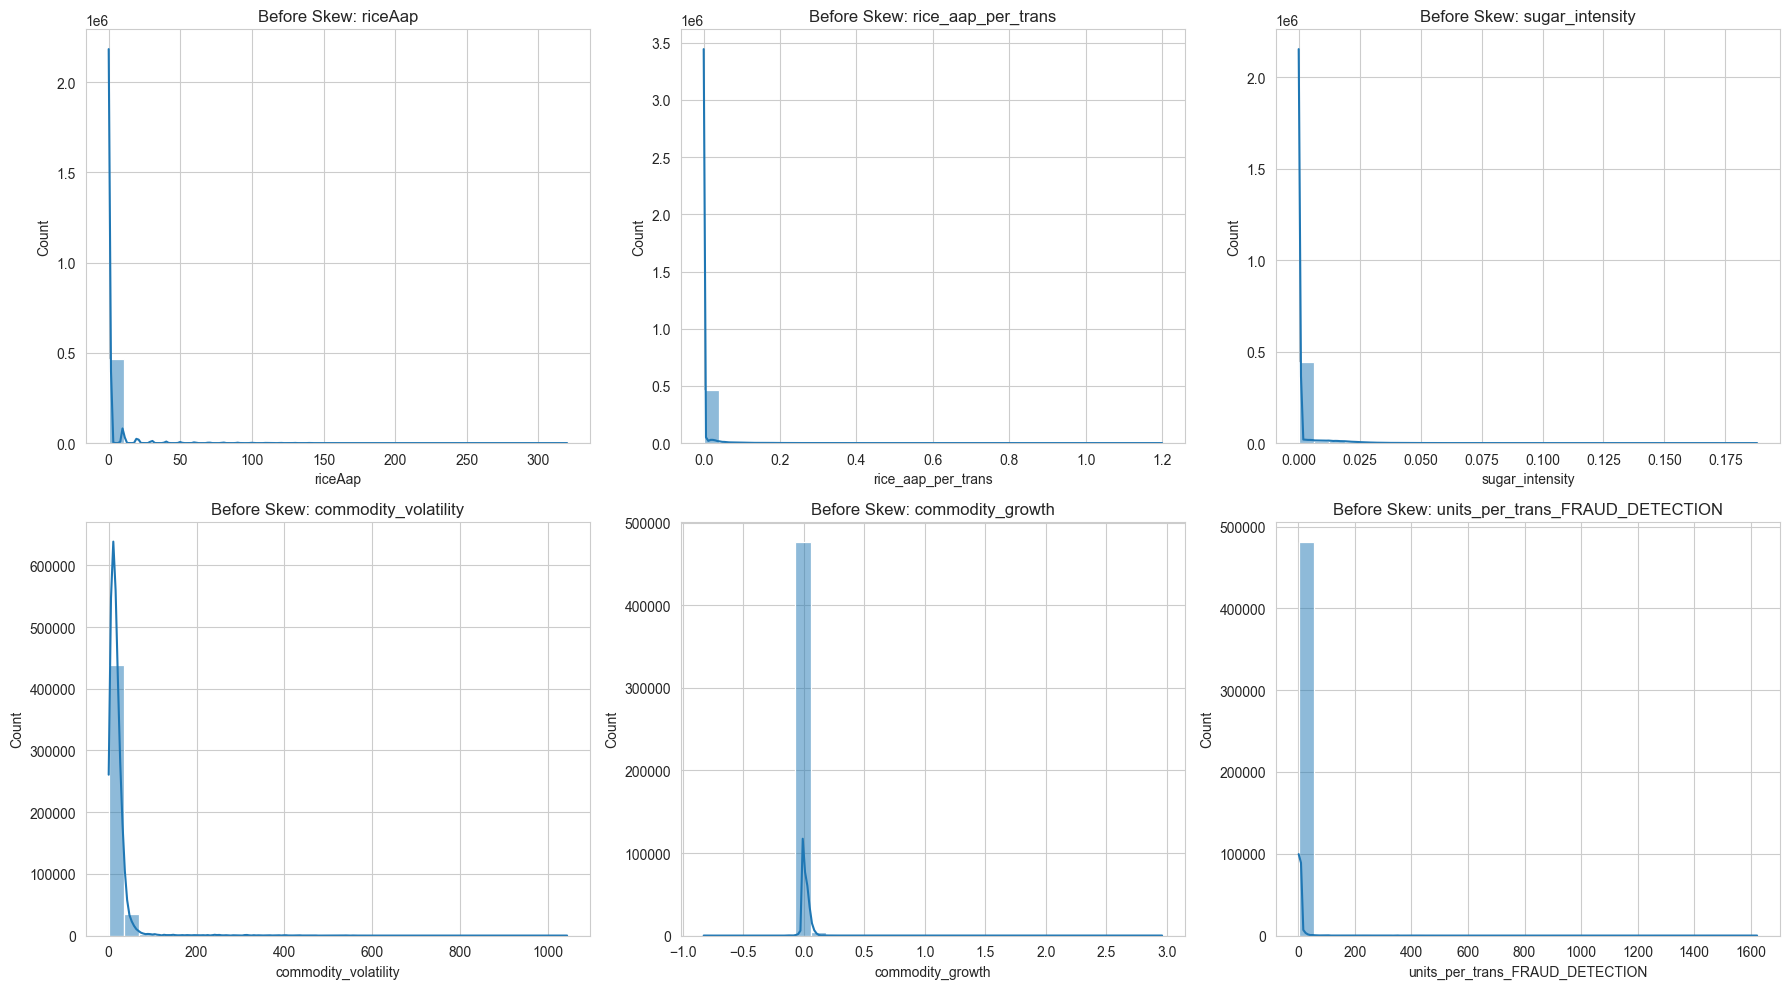

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

extreme_skew_cols = [
    'riceAap',
    'rice_aap_per_trans',
    'sugar_intensity',
    'commodity_volatility',
    'commodity_growth',
    'units_per_trans_FRAUD_DETECTION'
]

# grid size calculation
n_cols = 3
n_rows = (len(extreme_skew_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5*n_rows))

axes = axes.flatten()

for i, col in enumerate(extreme_skew_cols):
    sns.histplot(df[col], kde=True, bins=30, ax=axes[i])
    axes[i].set_title(f"Before Skew: {col}")

# remove empty subplots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [19]:
#After Applying Swkewness Treatment
for col in extreme_skew_cols:
    df[col] = np.log1p(df[col])

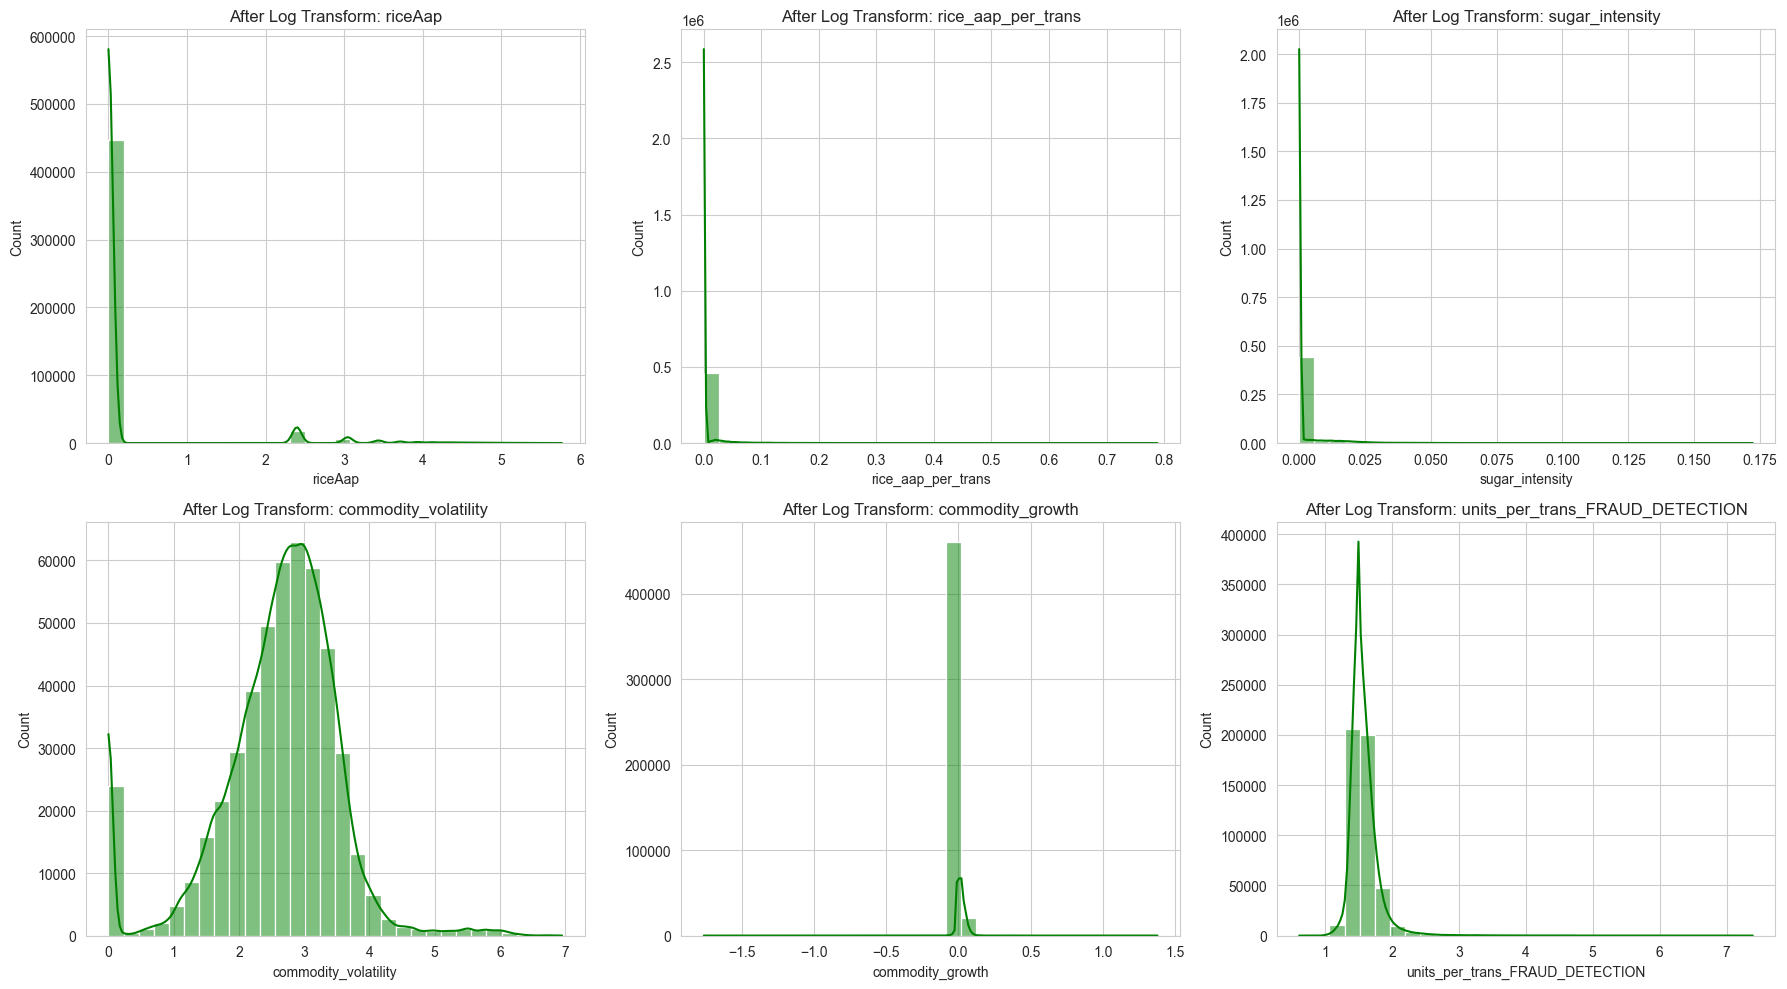

In [20]:
n_cols = 3
n_rows = (len(extreme_skew_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5*n_rows))

axes = axes.flatten()

# 📈 Plot AFTER transformation
for i, col in enumerate(extreme_skew_cols):
    sns.histplot(df[col], kde=True, bins=30, ax=axes[i], color="green")
    axes[i].set_title(f"After Log Transform: {col}")

# remove empty plots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [21]:
import numpy as np

# ✔ ONLY numeric continuous skewed columns
high_skew_cols = [
    'wheat',
    'sugar',
    'totalAmount',
    'riceAap_available',
    'wheat_available',
    'amount_per_transaction',
    'amount_per_card',
    'rice_afsc_per_trans',
    'wheat_per_trans',
    'transaction_volatility',
    'amount_volatility',
    'district_load',
    'availability_score'
]



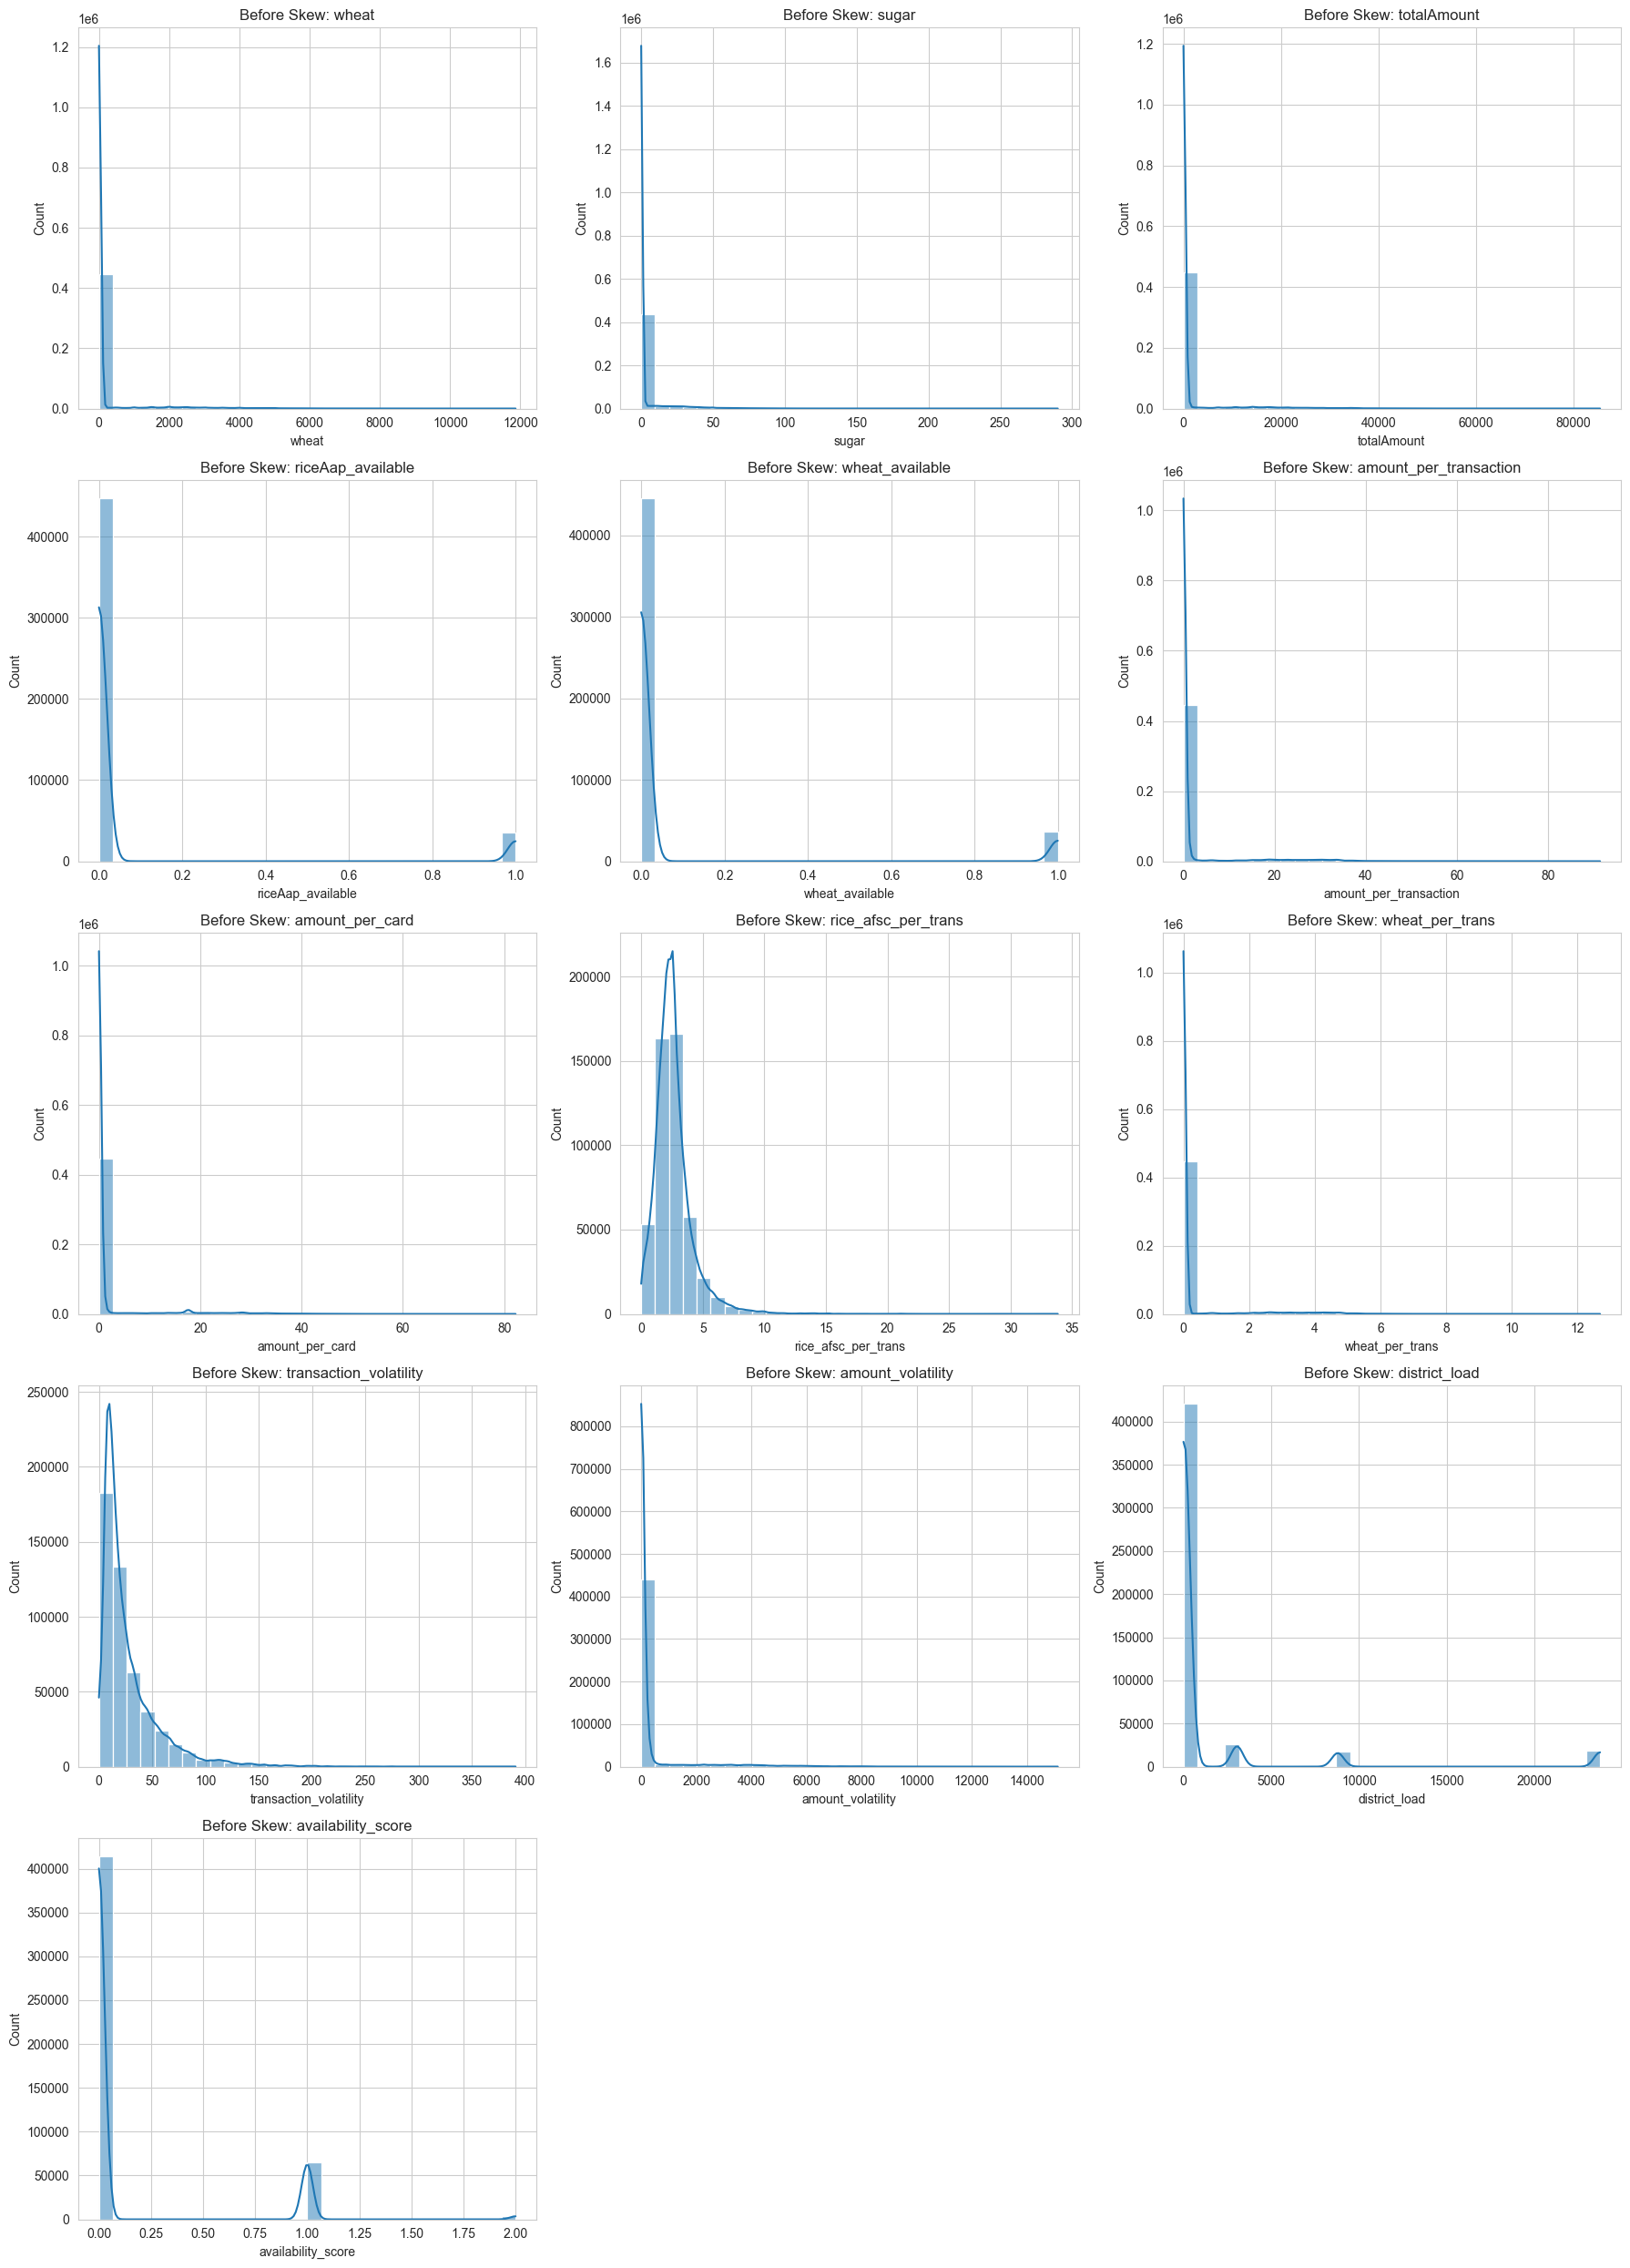

In [22]:
# 📊 GRID setup
n_cols = 3
n_rows = (len(high_skew_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5*n_rows))

axes = axes.flatten()

# 📈 BEFORE skew plots
for i, col in enumerate(high_skew_cols):
    sns.histplot(df[col], kde=True, bins=30, ax=axes[i])
    axes[i].set_title(f"Before Skew: {col}")

# remove empty plots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [23]:
for col in high_skew_cols:
    df[col] = np.log1p(df[col])

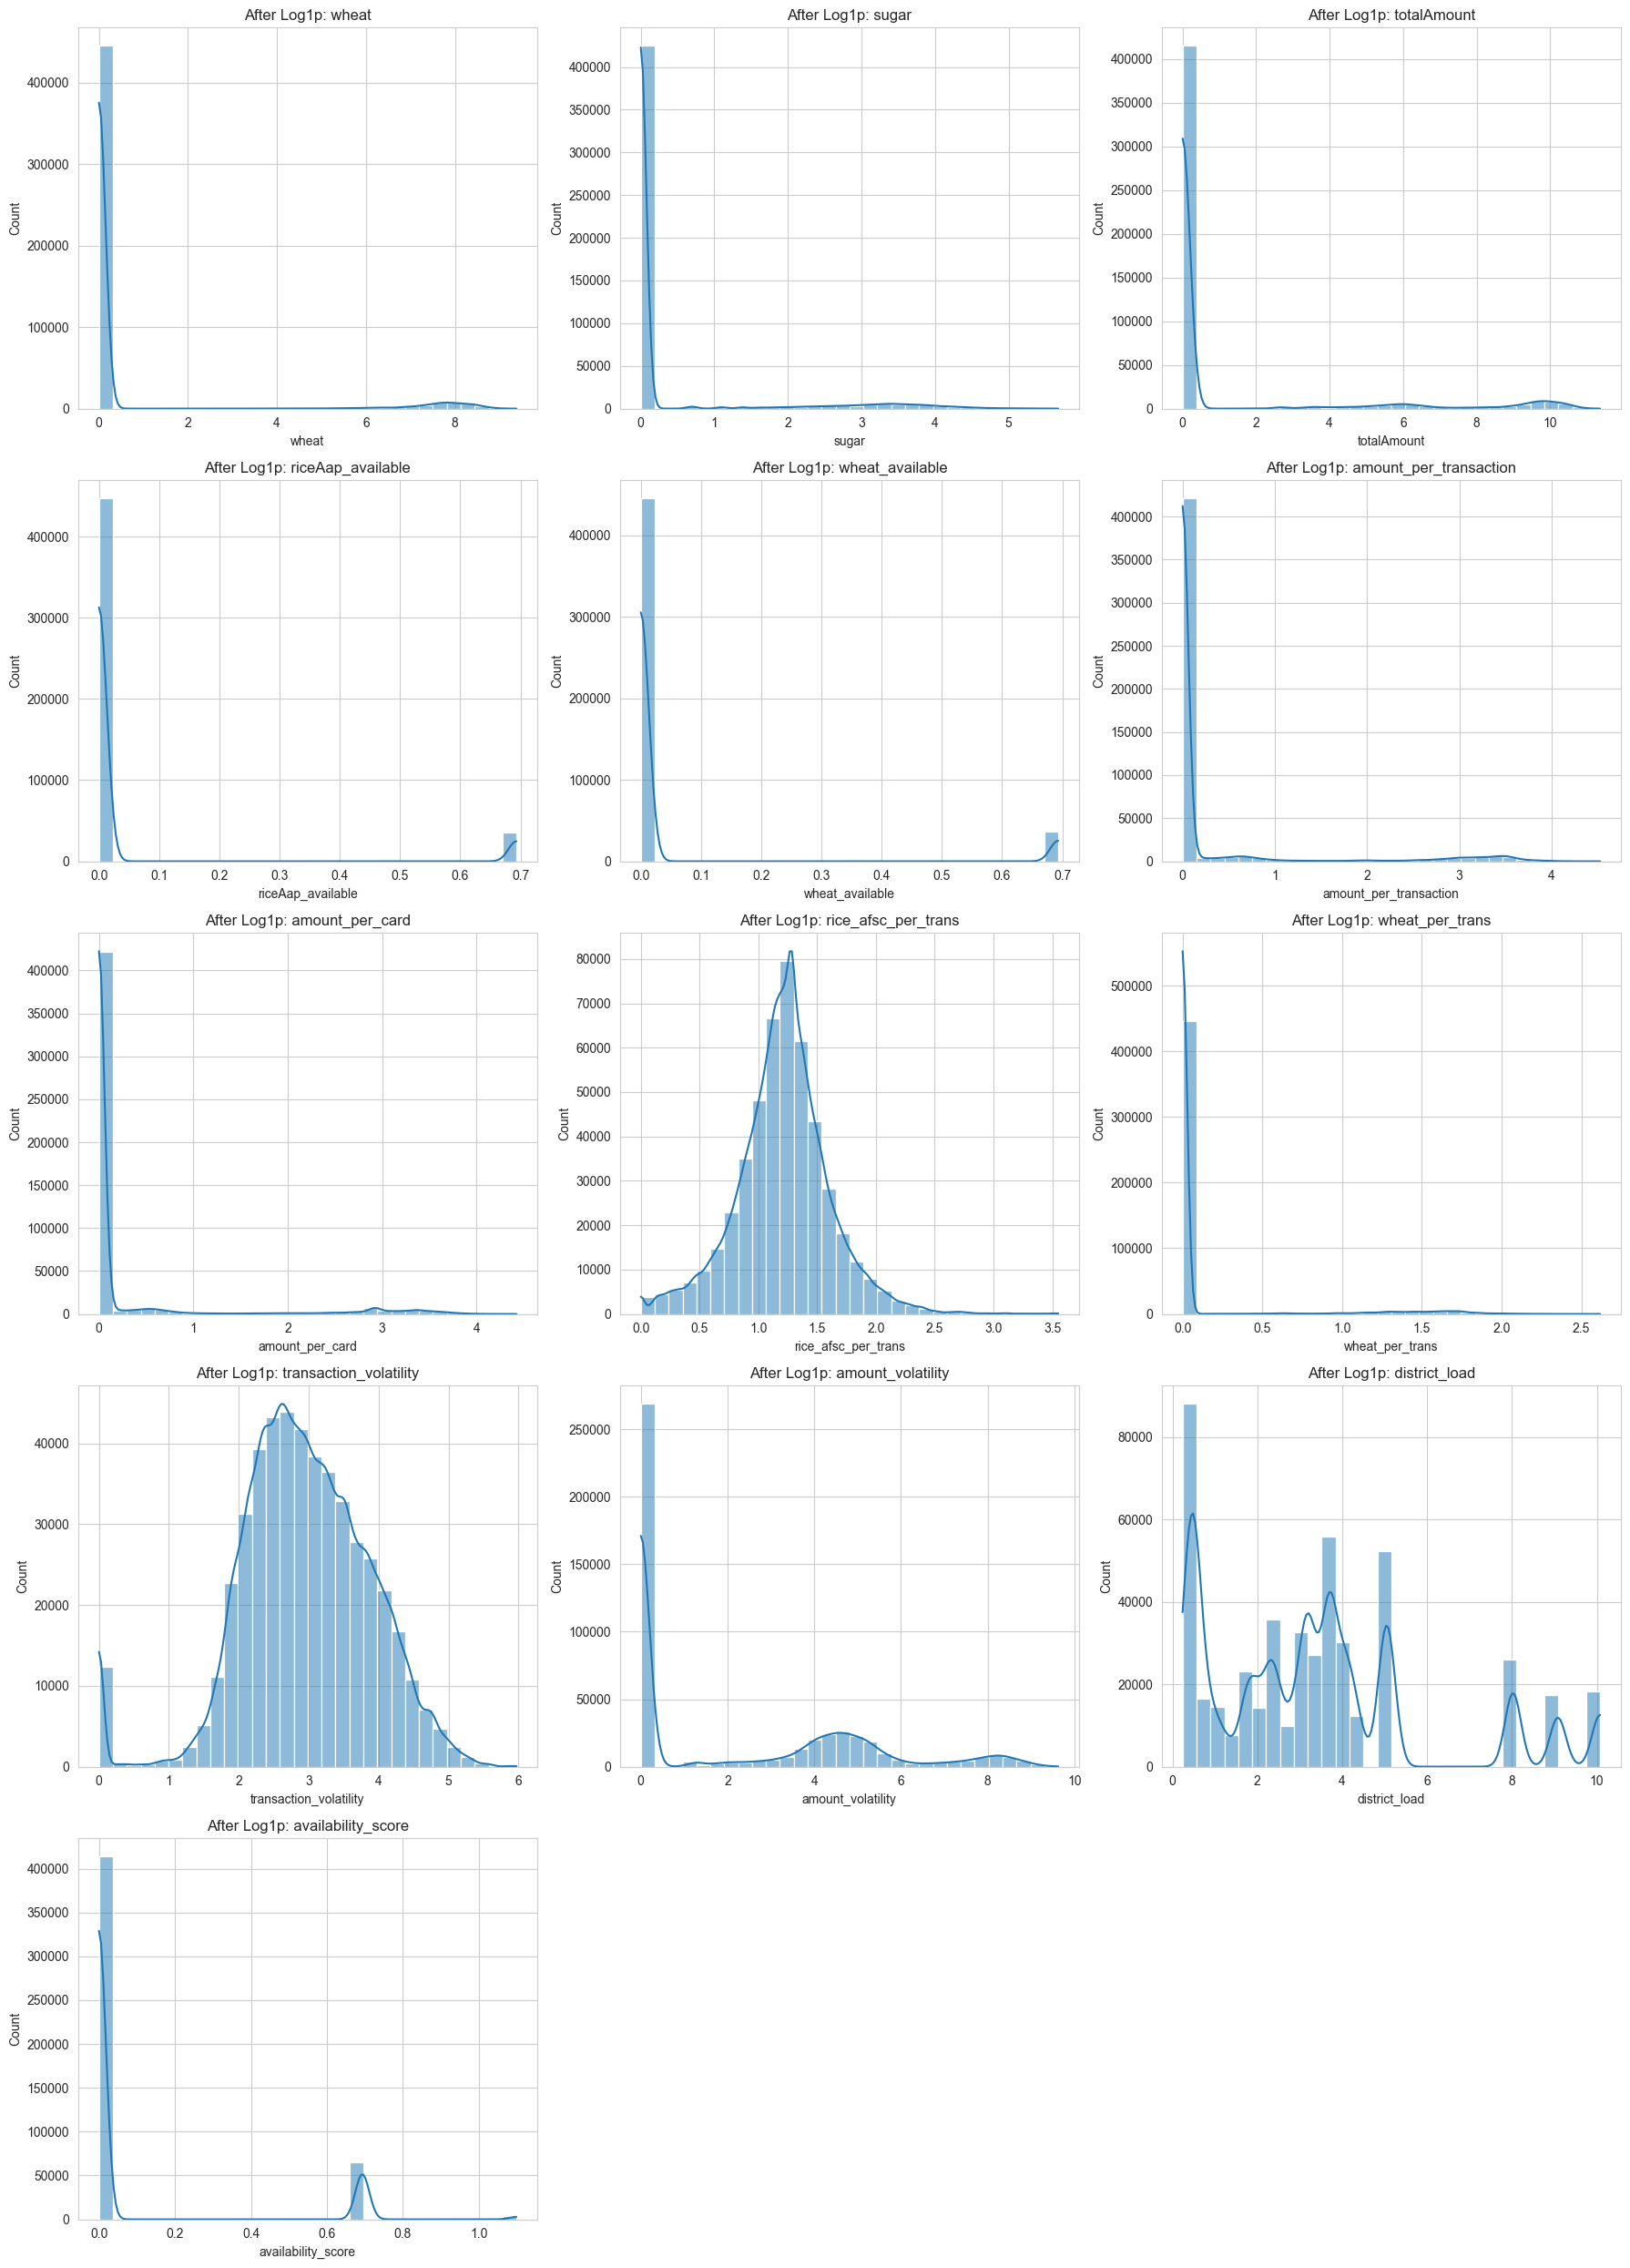

In [24]:
# 📊 GRID setup
n_cols = 3
n_rows = (len(high_skew_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5*n_rows))

axes = axes.flatten()

# 📈 AFTER log transform plots
for i, col in enumerate(high_skew_cols):
    sns.histplot(
        df[col],
        kde=True,
        bins=30,
        ax=axes[i]
    )
    axes[i].set_title(f"After Log1p: {col}")

# Remove empty plots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [25]:
import numpy as np

moderate_skew_cols = [
    'noOfRcs',
    'noOfTrans',
    'riceAfsc',
    'riceFsc',
    'totalRcs',
    'totalUnits',
    'otherShopTransCnt',
    'portability_hub_score',
    'portability_intensity',
    'other_shop_ratio',
    'distribution_change',
    'shop_density',
    'rice_wheat_ratio'
]



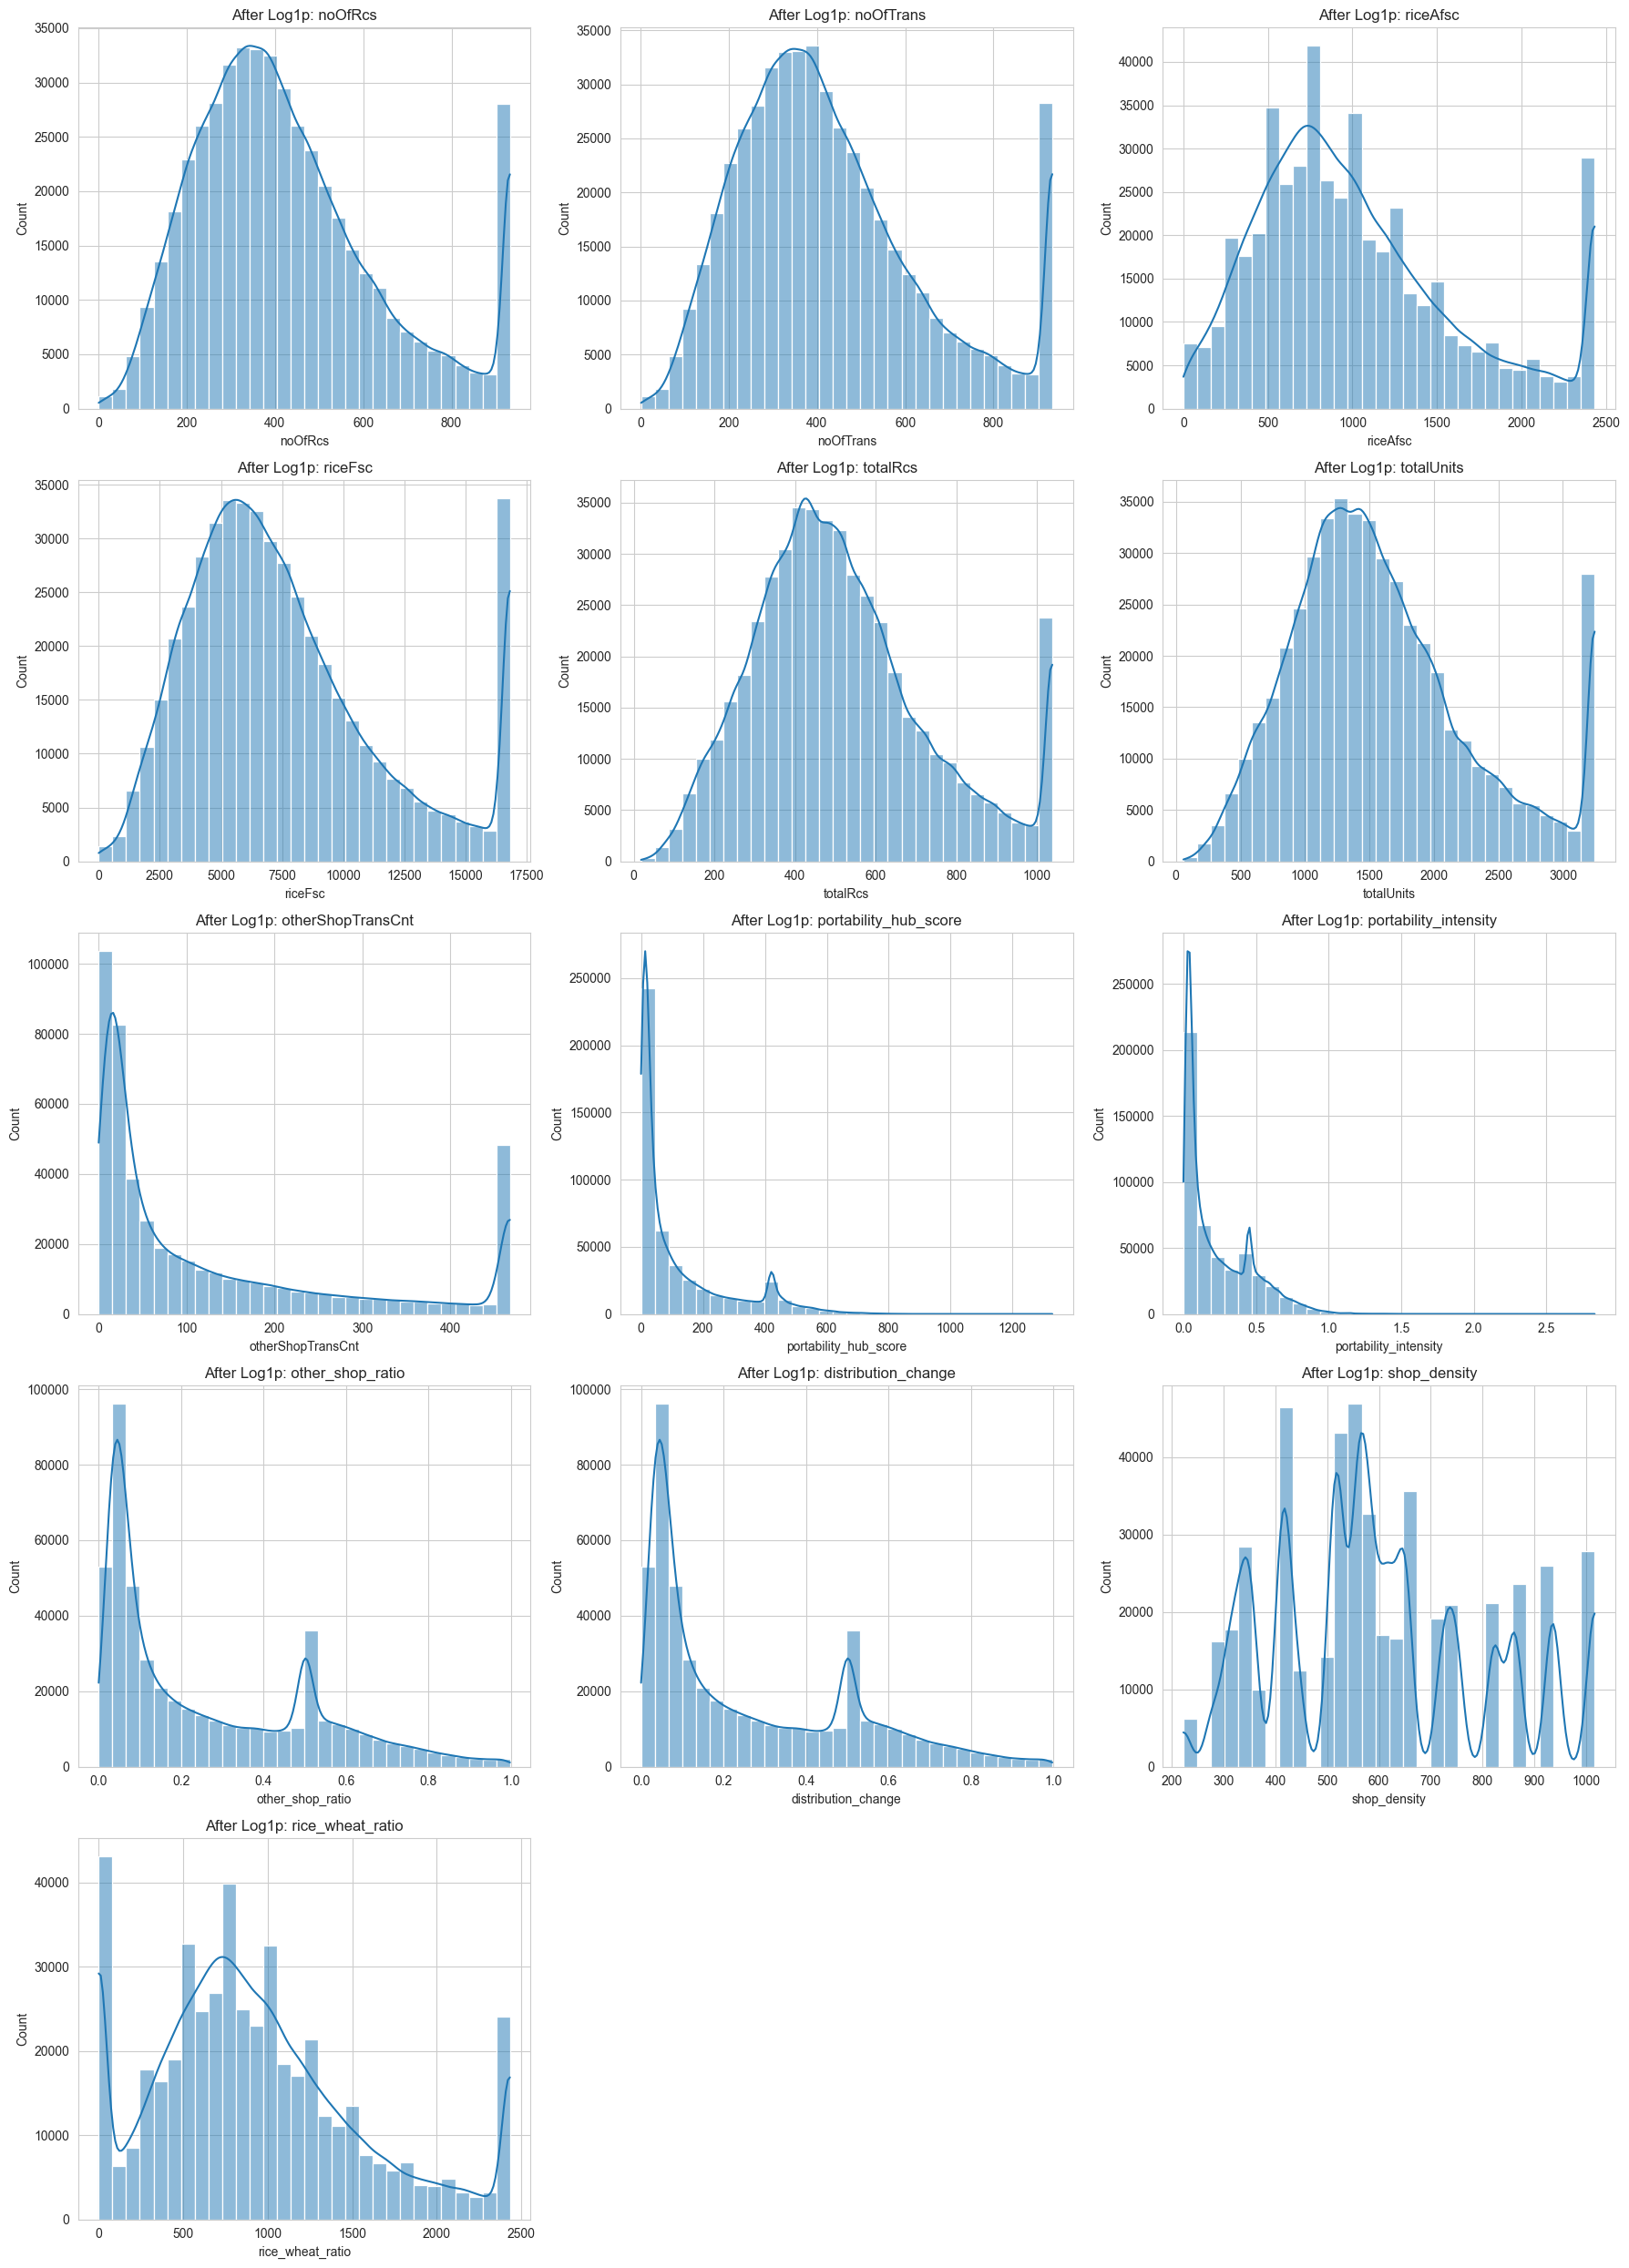

In [26]:
# Grid setup
n_cols = 3
n_rows = (len(moderate_skew_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5*n_rows))

axes = axes.flatten()

# AFTER skew plots
for i, col in enumerate(moderate_skew_cols):
    sns.histplot(
        df[col],
        kde=True,
        bins=30,
        ax=axes[i]
    )
    axes[i].set_title(f"After Log1p: {col}")
    axes[i].set_xlabel(col)

# Remove empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [28]:
for col in moderate_skew_cols:
    df[col] = np.log1p(df[col])

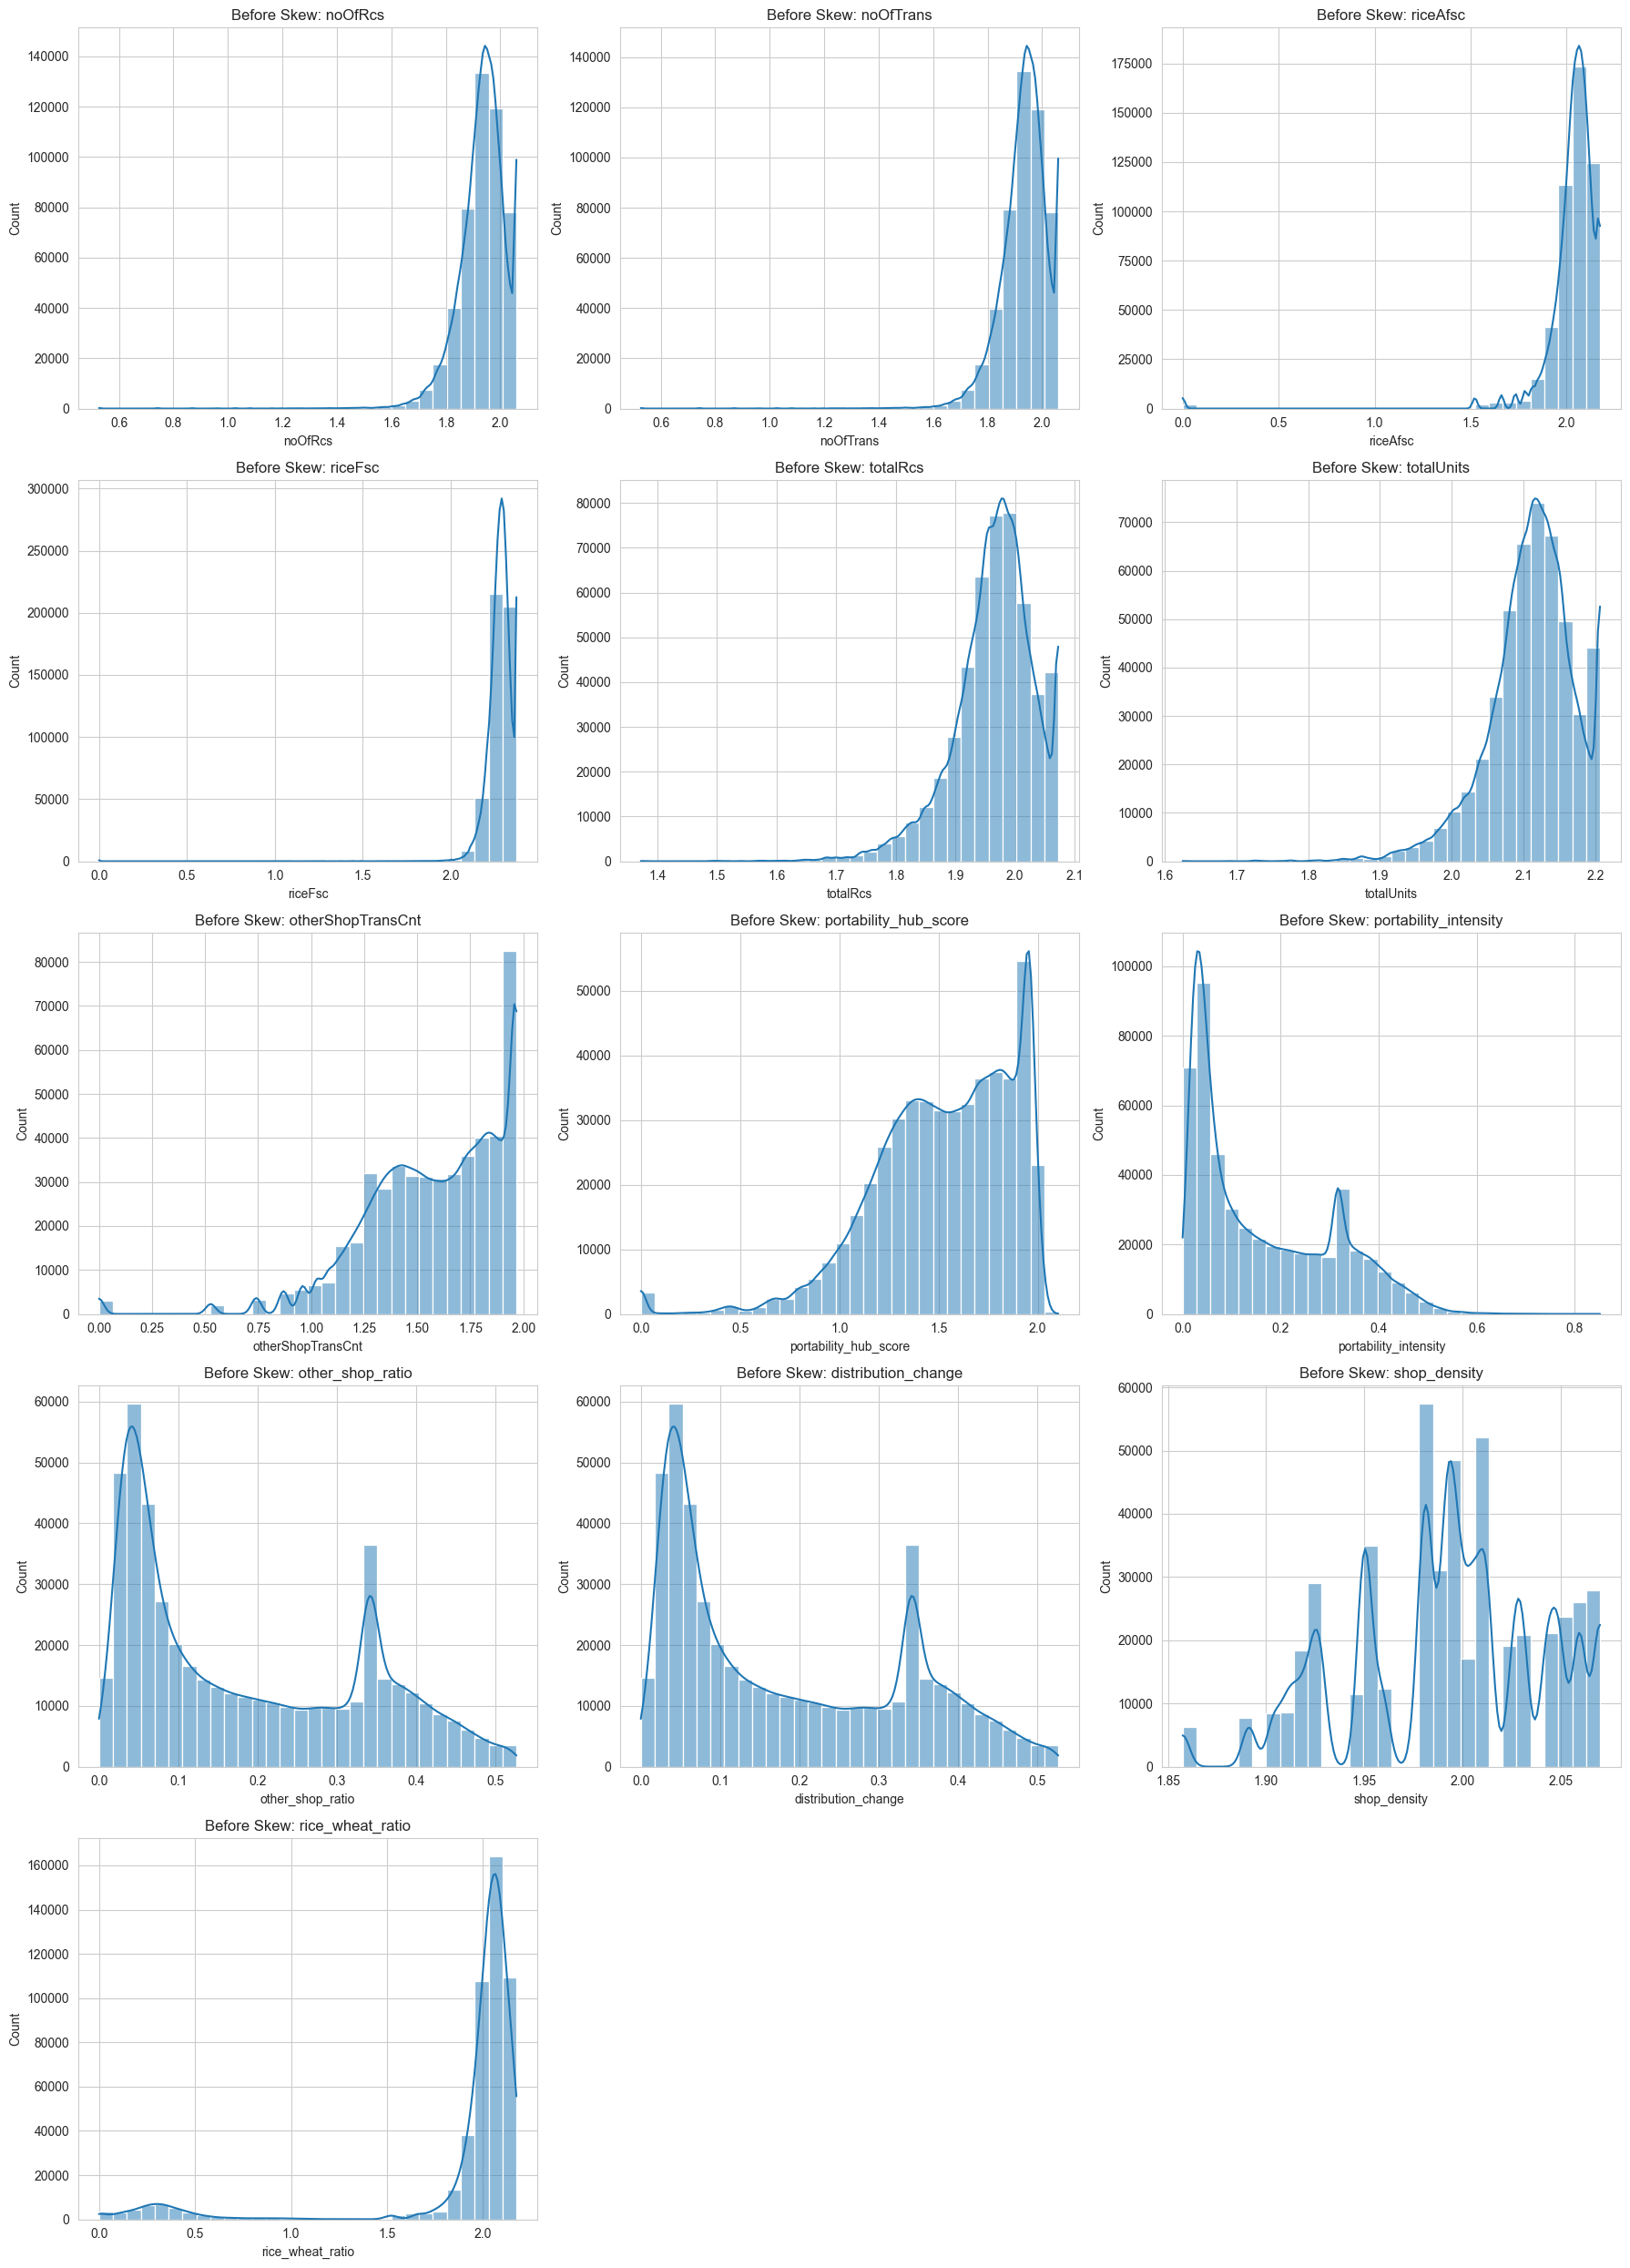

In [29]:
# Grid setup
n_cols = 3
n_rows = (len(moderate_skew_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5*n_rows))

axes = axes.flatten()

# After skew plots
for i, col in enumerate(moderate_skew_cols):
    sns.histplot(
        df[col],
        kde=True,
        bins=30,
        ax=axes[i]
    )
    axes[i].set_title(f"Before Skew: {col}")
    axes[i].set_xlabel(col)

# Remove empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [30]:
df.shape

(482117, 72)

In [31]:
# Missing values check
df.isnull().sum()

shopNo                             0
month                              0
year                               0
noOfRcs                            0
noOfTrans                          0
riceAfsc                           0
riceFsc                            0
riceAap                            0
wheat                              0
sugar                              0
totalAmount                        0
otherShopTransCnt                  0
riceAap_available                  0
wheat_available                    0
totalRcs                           0
totalUnits                         0
units                              0
distCode                           0
officeCode                         0
longitude                          0
latitude                           0
fpsStatus                          0
fpsType                            0
week                               0
quarter                            0
is_weekend                         0
day_of_year                        0
m

In [32]:
# Duplicate check
df.duplicated().sum()

np.int64(0)

In [33]:

print("\nData Types:\n", df.dtypes)


Data Types:
 shopNo                               int64
month                                int64
year                                 int64
noOfRcs                            float64
noOfTrans                          float64
riceAfsc                           float64
riceFsc                            float64
riceAap                            float64
wheat                              float64
sugar                              float64
totalAmount                        float64
otherShopTransCnt                  float64
riceAap_available                  float64
wheat_available                    float64
totalRcs                           float64
totalUnits                         float64
units                                int64
distCode                           float64
officeCode                         float64
longitude                          float64
latitude                           float64
fpsStatus                            int64
fpsType                              int

In [34]:
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns

print("Numerical Columns:")
print(list(numerical_columns))
print("Total:", len(numerical_columns))

Numerical Columns:
['shopNo', 'month', 'year', 'noOfRcs', 'noOfTrans', 'riceAfsc', 'riceFsc', 'riceAap', 'wheat', 'sugar', 'totalAmount', 'otherShopTransCnt', 'riceAap_available', 'wheat_available', 'totalRcs', 'totalUnits', 'units', 'distCode', 'officeCode', 'longitude', 'latitude', 'fpsStatus', 'fpsType', 'week', 'quarter', 'is_weekend', 'day_of_year', 'month_start', 'month_end', 'days_in_month', 'utilization_ratio', 'units_per_card', 'amount_per_transaction', 'amount_per_card', 'rice_afsc_per_trans', 'rice_fsc_per_trans', 'rice_aap_per_trans', 'wheat_per_trans', 'rice_to_wheat_ratio', 'sugar_intensity', 'wheat_intensity', 'rice_share', 'commodity_activity', 'other_shop_ratio', 'portability_hub_score', 'portability_intensity', 'high_non_local_flag', 'trans_per_card_FRAUD_DETECTION', 'units_per_trans_FRAUD_DETECTION', 'fraud_risk_flag', 'post_onorc', 'urban_proxy', 'distribution_change', 'transaction_volatility', 'amount_volatility', 'commodity_volatility', 'amount_growth', 'commodity

In [35]:
categorical_columns = df.select_dtypes(include=['object', 'category']).columns

print("Categorical Columns:")
print(list(categorical_columns))
print("Total:", len(categorical_columns))

Categorical Columns:
[]
Total: 0


In [37]:
df.to_csv("../data/Master_data/Encoding_data.csv", index=False)
print("data Save")

data Save


In [38]:
import os
import joblib
# Save PKL
joblib.dump(df, "../model/Encoding_data.pkl")
print("Files saved in models folder successfully!")


Files saved in models folder successfully!


In [39]:
import os
print(os.getcwd())

d:\Telangana PDS Analytics\notebook
